# Hazard assessment for windstorms — Kazakhstan

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[STORMS](https://github.com/CLIMAAX/STORMS) GitHub repository for use
with globally available data covering Kazakhstan.

## Data Substitutions

| Original CLIMAAX | Kazakhstan replacement | Reason |
|---|---|---|
| CDS `sis-european-wind-storm-reanalysis` (Option A) | **Removed** | Coverage is 25°W–35°E only; Kazakhstan is entirely outside domain |
| ERA5 wind gusts via CDS API (Option B) | **Kept unchanged** | ERA5 is fully global; same variable, same method |
| Storm Klaus (European event example) | **User-configured event** | No named-event catalogue exists for Central Asia; event dates are free parameters |
| Storm relocation ("future storms shift north") | **Removed** | Based on North Atlantic extratropical-cyclone dynamics; not applicable to Kazakhstan's wind regime |
| NUTS / EU administrative boundaries | Kazakhstan OSM shapefile (local) | EU-specific |

## Methodology

The storm footprint is the pixel-wise maximum 3-second wind gust (m/s) recorded
over the duration of a storm event, derived from ERA5 hourly
`10m_wind_gust_since_previous_post_processing`.
This is identical to the original CLIMAAX methodology (Option B).

**ERA5 access note:** Download requires a free Copernicus CDS account.
Register at https://cds.climate.copernicus.eu and place your UID and API key
in `~/.cdsapirc` (see https://cds.climate.copernicus.eu/how-to-api).

## Load libraries

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cdsapi
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import shape

## Configuration

Set the event window and the area of interest.

**Event window:** Set `storm_start` and `storm_end` to the UTC period that
brackets the storm you want to analyse. ERA5 wind gusts are available from
1940 to near-present.

**Bounding box:** `[west, south, east, north]` in decimal degrees.
The default covers all of Kazakhstan. Narrow it to a single oblast if needed.

**Storm label:** A short identifier used for file names and plot titles.

In [2]:
# --- User configuration ---

# Storm event window (inclusive, UTC)
storm_start   = "2023-11-17 00:00"  
storm_end     = "2023-11-19 23:00"  

# Short label for file names and plot titles
storm_name = "buran_nov2023"          # e.g. "buran_march2012"

# Bounding box [west, south, east, north] — full Kazakhstan default
bbox = [46.0, 40.0, 88.0, 56.0]

# Optional: restrict analysis to a single oblast (set to None for full country)
# Must match the 'oblast_en' field in the shapefile exactly.
oblast_filter = None   # e.g. "Akmola" or None

# CDS API credentials — leave None if ~/.cdsapirc is already configured
CDS_URL = "https://cds.climate.copernicus.eu/api"
CDS_KEY = None   # e.g. "your-uid:your-api-key"

## Paths

In [3]:
# Working directory is the notebook folder (VS Code Jupyter behaviour)
work_dir = Path(".")

workflow_folder  = work_dir / "STORM_event_raster"
general_data_dir = workflow_folder / "general_data"
data_dir         = workflow_folder / f"data_{storm_name}"
plot_dir         = workflow_folder / f"plots_{storm_name}"
results_dir      = workflow_folder / "results"

for d in [general_data_dir, data_dir, plot_dir, results_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Kazakhstan shapefile (national boundary)
shp_path = Path(
    r"C:\Users\dauzo\Models\crabook-kazakhstan\crabook"
    r"\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp"
)
OBLAST_FIELD = "oblast_en"

## Load Kazakhstan boundary

In [4]:
import re

kaz = gpd.read_file(shp_path)

if oblast_filter is not None:
    region_gdf = kaz[kaz[OBLAST_FIELD] == oblast_filter].dissolve()
    if region_gdf.empty:
        raise ValueError(
            f"No rows found for {OBLAST_FIELD} == '{oblast_filter}'. "
            f"Available: {kaz[OBLAST_FIELD].unique().tolist()}"
        )
    analysis_label = oblast_filter
    kaz_national   = region_gdf
else:
    analysis_label = "Kazakhstan"
    kaz_national   = gpd.GeoDataFrame(
        geometry=[kaz.geometry.unary_union], crs=kaz.crs
    )

coords_user = gpd.GeoSeries.get_coordinates(kaz_national).to_numpy()
print(f"Analysis region : {analysis_label}")
print(f"Lon range       : [{coords_user[:,0].min():.2f}, {coords_user[:,0].max():.2f}]")
print(f"Lat range       : [{coords_user[:,1].min():.2f}, {coords_user[:,1].max():.2f}]")
print(f"CRS             : {kaz.crs}")

C:\Users\dauzo\AppData\Local\Temp\ipykernel_27724\2329223613.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geometry=[kaz.geometry.unary_union], crs=kaz.crs


Analysis region : Kazakhstan
Lon range       : [46.49, 87.32]
Lat range       : [40.57, 55.44]
CRS             : EPSG:4326


## Compute storm footprint from ERA5

This is the only data option for Kazakhstan — the European windstorm
reanalysis (Option A in the original workflow) covers only 25°W–35°E
and cannot be used here.

We download hourly wind gust data from ERA5 for the configured event
window and derive the footprint as the pixel-wise maximum over time.

In [5]:
era5_gust_file = general_data_dir / f"{storm_name}_ERA5.nc"
footprint_file = data_dir / f"{storm_name}.nc"

# --- Download ERA5 hourly wind gusts ---
if era5_gust_file.exists():
    print(f"Cached: {era5_gust_file}")
else:
    if "YYYY" in storm_start or "YYYY" in storm_end:
        raise ValueError(
            "Set storm_start and storm_end in the Configuration cell before downloading. "
            f"Current values: storm_start={storm_start!r}, storm_end={storm_end!r}"
        )

    c = cdsapi.Client(url=CDS_URL, key=CDS_KEY)

    timesteps = pd.date_range(storm_start, storm_end, freq="1h")

    era5_zip_path = general_data_dir / f"{storm_name}_ERA5.zip"
    print("Requesting ERA5 wind gust data from CDS …")
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": ["10m_wind_gust_since_previous_post_processing"],
            "year":  [str(y) for y in timesteps.year.unique().tolist()],
            "month": [str(m).zfill(2) for m in timesteps.month.unique().tolist()],
            "day":   [str(d).zfill(2) for d in timesteps.day.unique().tolist()],
            "time":  [f"{h:02d}:00" for h in timesteps.hour.unique().tolist()],
            "data_format": "netcdf",
            "download_format": "zip",
            "area": [bbox[3], bbox[0], bbox[1], bbox[2]],  # CDS order: N, W, S, E
        },
        str(era5_zip_path),
    )
    with zipfile.ZipFile(era5_zip_path, "r") as z:
        for i, name in enumerate(z.namelist()):
            if Path(name).suffix == ".nc":
                era5_gust_file.write_bytes(z.read(name))
                break  # single-variable request produces one .nc file
    era5_zip_path.unlink()
    print(f"Downloaded and extracted: {era5_gust_file}")

# --- Compute footprint ---
if footprint_file.exists():
    print(f"Cached: {footprint_file}")
else:
    ds = xr.open_dataset(str(era5_gust_file))
    print("Variables in file:", list(ds.data_vars))
    print("Dimensions:", dict(ds.sizes))
    print("Coordinates:", list(ds.coords))

    # Pick the wind gust variable (name varies by ERA5 vintage)
    gust_var = next(
        v for v in ds.data_vars
        if "gust" in v.lower() or v.lower() in ("fg", "fx", "i10fg", "fg10")
        or v.lower().startswith("fg")
    )
    print(f"Using variable: {gust_var!r}")

    time_dim = "valid_time" if "valid_time" in ds.dims else "time"
    gust_data = ds[gust_var].sel({time_dim: slice(storm_start, storm_end)})
    print("Min gust (m/s):", float(gust_data.min()))
    print("Max gust (m/s):", float(gust_data.max()))

    windstorm_region = (
        gust_data
        .max(dim=time_dim)              # pixel-wise maximum → footprint
        .rename("FX")
        .rename({"latitude": "y", "longitude": "x"})
        .rio.set_spatial_dims(x_dim="x", y_dim="y")
        .rio.write_crs("EPSG:4326")
    )

    windstorm_region.to_netcdf(str(footprint_file))
    print(f"Saved footprint: {footprint_file}")

Requesting ERA5 wind gust data from CDS …


2026-04-18 17:13:10,125 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-04-18 17:13:10,125 INFO Request ID is 4f03c289-9568-4ef4-9459-96d914615c16
2026-04-18 17:13:10,522 INFO status has been updated to accepted
2026-04-18 17:13:24,635 INFO status has been updated to running
2026-04-18 17:13:32,352 INFO status has been updated to successful


81330722e286a0d224011c5f3b4b818d.zip:   0%|          | 0.00/1.62M [00:00<?, ?B/s]

Downloaded and extracted: STORM_event_raster\general_data\buran_nov2023_ERA5.nc
Variables in file: ['fg10']
Dimensions: {'valid_time': 72, 'latitude': 65, 'longitude': 169}
Coordinates: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
Using variable: 'fg10'
Min gust (m/s): 0.3897082209587097
Max gust (m/s): 32.40599822998047
Saved footprint: STORM_event_raster\data_buran_nov2023\buran_nov2023.nc


## Load footprint for visualisation

Run this cell whether you just computed the footprint above or are
reloading a previously saved file.

In [6]:
windstorm_region = xr.open_dataarray(
    str(footprint_file),
    decode_coords="all"
)

print("Footprint summary")
print(f"  Shape : {windstorm_region.shape}")
print(f"  Min   : {float(windstorm_region.min()):.1f} m/s")
print(f"  Max   : {float(windstorm_region.max()):.1f} m/s")
print(f"  Resolution: {windstorm_region.rio.resolution()}")

Footprint summary
  Shape : (65, 169)
  Min   : 3.6 m/s
  Max   : 32.4 m/s
  Resolution: (0.25, -0.25)


## Visualise storm footprint

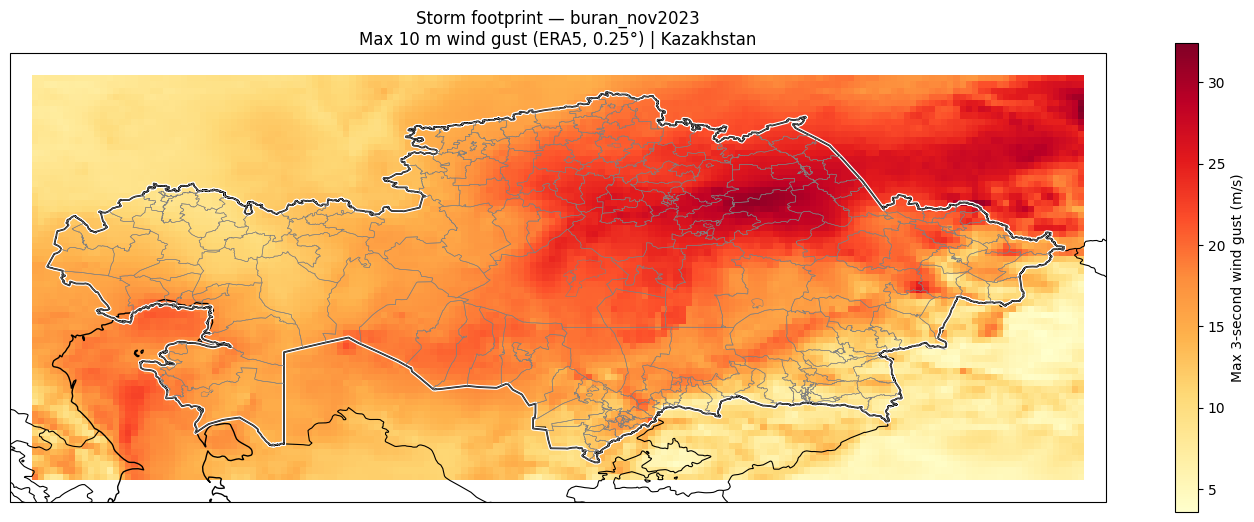

Saved: STORM_event_raster\plots_buran_nov2023\footprint_buran_nov2023_Kazakhstan.png


In [7]:
# Helper: extract boundary ring coordinates from a multi-part shapefile
# without drawing artifact lines across Kazakhstan.
def get_boundary_coords(geom):
    """Yield (lons, lats) pairs for each part of a Polygon or MultiPolygon."""
    if geom.geom_type == "Polygon":
        yield np.array(geom.exterior.coords)[:, 0], np.array(geom.exterior.coords)[:, 1]
    elif geom.geom_type == "MultiPolygon":
        for part in geom.geoms:
            yield np.array(part.exterior.coords)[:, 0], np.array(part.exterior.coords)[:, 1]

fig, ax = plt.subplots(
    figsize=(14, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Plot ERA5 footprint (max gust in m/s)
windstorm_region.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    cbar_kwargs={"label": "Max 3-second wind gust (m/s)", "shrink": 0.7}
)

# Overlay Kazakhstan boundary (multi-part safe)
for geom in kaz_national.geometry:
    for lons, lats in get_boundary_coords(geom):
        ax.plot(
            lons, lats,
            transform=ccrs.PlateCarree(),
            color="black",
            linewidth=1.2,
            path_effects=[pe.withStroke(linewidth=3, foreground="white")]
        )

# Optional: oblast boundaries
for geom in kaz.geometry:
    for lons, lats in get_boundary_coords(geom):
        ax.plot(
            lons, lats,
            transform=ccrs.PlateCarree(),
            color="grey",
            linewidth=0.4
        )

ax.coastlines(resolution="50m")
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.set_extent(
    [bbox[0] - 1, bbox[2] + 1, bbox[1] - 1, bbox[3] + 1],
    crs=ccrs.PlateCarree()
)
ax.set_title(
    f"Storm footprint — {storm_name}\n"
    f"Max 10 m wind gust (ERA5, 0.25°) | {analysis_label}",
    fontsize=12
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
fig_path = plot_dir / f"footprint_{storm_name}_{analysis_label}.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## Save footprint to results

In [8]:
result_path = results_dir / f"footprint_{storm_name}.nc"
windstorm_region.to_netcdf(str(result_path))
print(f"Result saved: {result_path}")

Result saved: STORM_event_raster\results\footprint_buran_nov2023.nc


## Conclusions

This hazard notebook produces a storm footprint — a raster of maximum
10 m wind gust speed (m/s) over the duration of a chosen event — for any
historical storm in ERA5 (1940 to near-present) over Kazakhstan or a
sub-region.

**Key differences from the original CLIMAAX workflow:**

- **Option A removed:** The European windstorm reanalysis dataset
  (`sis-european-wind-storm-reanalysis`) covers 25°W–35°E only and
  cannot be used for Kazakhstan.
- **Storm relocation removed:** The "shift footprint north" feature was
  based on North Atlantic extratropical-cyclone dynamics and has no
  scientific basis for Kazakhstan's wind regime (continental anticyclone
  breakdowns, arctic air-mass intrusions, steppe-channel effects).
- **ERA5 retained:** The ERA5 Option B methodology is identical to the
  original. ERA5 is fully global and the same `cdsapi` workflow applies.

**Limitations:**
- ERA5 resolution is 0.25° (~28 km). This underestimates peak gusts
  compared to downscaled or observational products. Use caution when
  applying damage curves calibrated against observed gusts.
- A free CDS account is required for ERA5 downloads.

The footprint file can now be used in the risk assessment notebook.

## References

- Koks, E.E., Haer, T. (2020). A high-resolution wind damage model for
  Europe. *Scientific Reports*, 10, 6866.
  DOI: [10.1038/s41598-020-63580-w](https://doi.org/10.1038/s41598-020-63580-w)
- Hersbach, H. et al. (2020). The ERA5 global reanalysis. *QJRMS*, 146,
  1999–2049. DOI: [10.1002/qj.3803](https://doi.org/10.1002/qj.3803)